# 05 - Evaluación: Evaluación Comparativa de Modelos

**Fase del Pipeline DSR: Evaluación y Recomendación de Despliegue**

Este notebook realiza la evaluación comparativa completa de los 4 modelos
de detección de anomalías no supervisados usando:
- **Métricas intrínsecas:** Silhouette, Davies-Bouldin, Calinski-Harabasz (calidad del cluster)
- **Métricas extrínsecas:** Accuracy, Sensibilidad, Especificidad, F1, AUC-ROC (vs verdad de campo AAMI)
- **Métricas de eficiencia:** Tiempo de entrenamiento, uso máximo de memoria

El `ModelComparator` ejecuta todos los modelos y produce una tabla de comparación unificada.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from ecg_anomaly.config import SystemConfig
from ecg_anomaly.seeding import set_global_seed
from ecg_anomaly.cache import get_or_build_preprocessed
from ecg_anomaly.data.splitting import make_normal_fit_split
from ecg_anomaly.features.manual import ManualFeatureExtractor
from ecg_anomaly.evaluation.comparator import ModelComparator
from ecg_anomaly.evaluation.extrinsic import evaluate_extrinsic
from ecg_anomaly.evaluation.intrinsic import evaluate_intrinsic
from ecg_anomaly.visualization.reports import plot_metrics_comparison, plot_confusion_matrices
from ecg_anomaly.visualization.clusters import plot_pca_scatter
from ecg_anomaly.visualization.labels import LABELS_ES

sns.set_style("whitegrid")
config = SystemConfig.from_yaml("../config/default.yaml")
config.setup_logging()
set_global_seed(config.random_seed)

## 1. Preparar Datos (Pipeline Completo)

In [2]:
preprocessed = get_or_build_preprocessed(config)

# Split solo-normal: evita fuga de datos en el escalado del autoencoder
# (ver guia de mejoras #1, y la nota metodologica mas abajo)
fit_idx, eval_idx = make_normal_fit_split(preprocessed, seed=config.random_seed)

# Path B: Manual features con ventanas temporales (22 features)
extractor = ManualFeatureExtractor()
X_clustering = extractor.extract(
    preprocessed.segments,
    preprocessed.r_peaks_flat,
    config.sampling_rate,
    preprocessed.record_indices,
)
# El scaler del autoencoder se ajusta SOLO con normales (fit_idx) y se
# aplica a todo el dataset: el autoencoder debe aprender como es un
# latido normal sin haber "visto" anomalias ni normales de evaluacion.
ae_scaler = StandardScaler()
ae_scaler.fit(preprocessed.segments[fit_idx])
X_autoencoder = ae_scaler.transform(preprocessed.segments)
true_labels = preprocessed.labels

# PCA 2D for visualization only
pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X_clustering)

print(f"Dataset: {preprocessed.metadata['n_beats']:,} beats from {preprocessed.metadata['n_records']} records")
print(f"Clustering features (Manual 22d): {X_clustering.shape}")
print(f"Autoencoder features (raw): {X_autoencoder.shape}")
print(f"Fit solo-normal: {len(fit_idx):,} | Eval: {len(eval_idx):,}")
print(f"Class distribution: Normal={int(np.sum(true_labels==0)):,}, Anomalous={int(np.sum(true_labels==1)):,}")

[cache] Cargando preprocesamiento desde pp_lc0.5_hc40.0_ord4_b90_a110.joblib


18:43:17 [ecg_anomaly.features.manual] INFO: Features manuales: 100705 latidos x 22 features


Dataset: 100,705 beats from 44 records
Clustering features (Manual 22d): (100705, 22)
Autoencoder features (raw): (100705, 200)
Fit solo-normal: 72,079 | Eval: 28,626
Class distribution: Normal=90,099, Anomalous=10,606


**Por que un split solo-normal:** ajustar el `StandardScaler` (y, en la Ruta A, el PCA) sobre todo el dataset -- incluyendo lo que luego se evalua -- contamina la estimacion de rendimiento del autoencoder. El estandar en deteccion de anomalias es aprender la representacion de "normalidad" solo con latidos normales (`fit_idx`) y aplicarla al resto (`eval_idx` = normales restantes + todas las anomalias), para que las anomalias destaquen por su error de reconstruccion. Por eso el autoencoder tambien se entrena mas abajo solo con `X_autoencoder[fit_idx]` (ver seccion 2). Para los modelos de clustering puro (K-Means, DBSCAN, HDBSCAN) este split es buena practica pero opcional, porque no hay entrenamiento supervisado que pueda sobreajustarse: siguen usando `X_clustering` completo. Ver guia de mejoras #1.

## 1b. ¿Por qué métricas intrínsecas y extrínsecas?

### Métricas Intrínsecas (No supervisadas)
Silhouette, Davies-Bouldin y Calinski-Harabasz evalúan la **calidad geométrica** de los clusters sin usar etiquetas. Esto refleja el escenario no supervisado real donde no hay ground truth disponible. Un Silhouette alto y Davies-Bouldin bajo indican clusters bien separados, condición necesaria para una detección de anomalías confiable.

### Métricas Extrínsecas (Evaluación supervisada)
Accuracy, Sensitivity, Specificity, F1 y AUC-ROC comparan las predicciones contra el estándar de oro clínico AAMI. Esto permite:
1. **Cuantificar el rendimiento clínico** de cada método
2. **Comparar contra la literatura publicada**
3. **Identificar tipos de error** (FP vs FN) que comete cada método

### ¿Por qué ambas?
Las métricas intrínsecas indican si el modelo encuentra **estructura geométrica significativa**. Las extrínsecas indican si esa estructura **corresponde a patología real**. Un modelo puede tener excelente geometría (Silhouette alto) pero mal alineamiento clínico (F1 bajo), o viceversa. Ambas perspectivas son necesarias para una evaluación completa.

**Nota clínica:** En el screening ECG médico, **los falsos negativos (anomalías no detectadas) son más críticos** que los falsos positivos (falsas alarmas). Un modelo que omite anomalías es clínicamente inútil sin importar su Accuracy. Por lo tanto, **Sensitivity** es una métrica clave a monitorear.

## 1c. Asignación heurística cluster-a-clase

Los cuatro métodos usan **reglas heurísticas** para mapear salidas no supervisadas a etiquetas binarias normal/anómalo:

| Método | Regla Heurística |
|--------|------------------|
| K-Means | Cluster minoritario (por tamaño) = anómalo |
| DBSCAN | Puntos de ruido (etiqueta = -1) = anómalo |
| HDBSCAN | Puntos de ruido (etiqueta = -1) = anómalo |
| Autoencoder | Latidos con error de reconstrucción > percentil umbral = anómalo |

**Limitación:** Estos supuestos deben validarse clínicamente. Por ejemplo, K-Means asume que el cluster más pequeño siempre contiene latidos patológicos, pero podría capturar una variante normal o artefactos. La siguiente celda prueba ambas direcciones de asignación para K-Means.

**Explicación de la validación:**

Este bloque verifica si la heurística por defecto de K-Means
(cluster minoritario = anómalo) es clínicamente correcta.
K-Means separa los datos en 2 clusters pero no sabe cuál es
normal y cuál es anómalo — la asignación es puramente geométrica.

Se prueban ambas direcciones contra el ground truth AAMI:
- **Asignación A**: cluster mayoritario = normal (heurística por defecto)
- **Asignación B**: cluster minoritario = normal (heurística invertida)

Si la asignación B obtiene mejor F1, la heurística por defecto
no es óptima para estos datos, lo que significa que el cluster
más grande podría contener las anomalías en lugar del más pequeño.

> **Nota metodológica:** La comparación de asignaciones A/B que sigue es un *análisis post-hoc de sensibilidad*, no parte del método de detección. En despliegue real, la asignación cluster→clase se define por una heurística no supervisada (cluster mayoritario = normal, sin mirar las etiquetas). Aquí solo cuantificamos cuánto rendimiento se pierde cuando esa heurística no coincide con la asignación óptima según el ground truth AAMI.

In [3]:
# Ejecutar el comparador PRIMERO y reutilizar su K-Means ya entrenado
# en vez de re-entrenarlo aqui (ver guia de mejoras #7: evita ajustar
# K-Means dos veces, cada vez con la posibilidad de una particion
# distinta si no se fija random_state en ambos sitios).
comparator = ModelComparator(config)
results_df = comparator.run_all(
    X_clustering, X_autoencoder, true_labels, autoencoder_fit_idx=fit_idx
)

kmeans_idx = config.models.index("kmeans")
kmeans = comparator.detectors[kmeans_idx]  # mismo objeto, mismas labels_

unique, counts = np.unique(kmeans.labels_, return_counts=True)
majority = unique[np.argmax(counts)]
minority = unique[np.argmin(counts)]

# Asignacion A: cluster mayoritario = normal (heuristica por defecto)
labels_a = np.where(kmeans.labels_ == majority, 0, 1)
metrics_a = evaluate_extrinsic(true_labels, labels_a)

# Asignacion B: cluster minoritario = normal (heuristica invertida)
labels_b = np.where(kmeans.labels_ == minority, 0, 1)
metrics_b = evaluate_extrinsic(true_labels, labels_b)

print("Comparacion de asignaciones K-Means:")
print(f"  Tamano clusters: mayoritario={counts[np.argmax(counts)]:,}, "
      f"minoritario={counts[np.argmin(counts)]:,}")
print(f"  Asignacion A (cluster {majority} = normal, cluster {minority} = anomalo):")
print(f"    F1={metrics_a['f1']:.4f}, Sensitivity={metrics_a['sensitivity']:.4f}, "
      f"Specificity={metrics_a['specificity']:.4f}")
print(f"  Asignacion B (cluster {minority} = normal, cluster {majority} = anomalo):")
print(f"    F1={metrics_b['f1']:.4f}, Sensitivity={metrics_b['sensitivity']:.4f}, "
      f"Specificity={metrics_b['specificity']:.4f}")

# --- Interpretacion corregida del experimento A/B ---
min_size = counts.min()
colapso = min_size < (0.01 * len(kmeans.labels_))  # cluster < 1% del total

print(f"\nDiagnostico del clustering K-Means:")
if colapso:
    print(f"  [!] CLUSTER DEGENERADO: el cluster minoritario tiene solo "
          f"{min_size:,} punto(s).")
    print(f"  K-Means no separo dos grupos reales: agrupo casi todo en uno")
    print(f"  y aislo un outlier. Ninguna asignacion A/B es clinicamente valida.")
    print(f"  La Especificidad=0.0 de la asignacion B confirma que el modelo")
    print(f"  clasificaria TODO como anomalo (no es 'mejor alineacion', es colapso).")
    print(f"  -> Este resultado justifica el uso de metodos de densidad")
    print(f"     (DBSCAN/HDBSCAN) y reconstruccion (autoencoder).")
else:
    best = 'A' if metrics_a['f1'] >= metrics_b['f1'] else 'B'
    print(f"  Clusters de tamano razonable. Mejor asignacion por F1: {best}")
    print(f"  (Analisis post-hoc de sensibilidad, no parte del metodo de deteccion.)")


18:43:18 [ecg_anomaly.evaluation.comparator] INFO: Evaluando kmeans...
18:45:20 [ecg_anomaly.evaluation.comparator] INFO: kmeans completado: F1=0.395, Silhouette=0.155, Tiempo=5.49s
18:45:20 [ecg_anomaly.evaluation.comparator] INFO: Evaluando dbscan...
18:45:37 [ecg_anomaly.models.dbscan] INFO: DBSCAN eps auto-optimizado (p90): 1.5412
18:47:35 [ecg_anomaly.evaluation.comparator] INFO: dbscan completado: F1=0.203, Silhouette=-0.050, Tiempo=28.58s
18:47:35 [ecg_anomaly.evaluation.comparator] INFO: Evaluando hdbscan...
18:52:01 [ecg_anomaly.models.hdbscan_model] INFO: HDBSCAN: 202 clusters, 45730 ruido (45.4%)
18:52:35 [ecg_anomaly.evaluation.comparator] INFO: hdbscan completado: F1=0.262, Silhouette=0.281, Tiempo=266.48s
18:52:35 [ecg_anomaly.evaluation.comparator] INFO: Evaluando autoencoder...
18:52:35 [tensorflow] WARNING: TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the Ten

Comparacion de asignaciones K-Means:
  Tamano clusters: mayoritario=30,209, minoritario=1
  Asignacion A (cluster 3 = normal, cluster 1 = anomalo):
    F1=0.0897, Sensitivity=0.3429, Specificity=0.2579
  Asignacion B (cluster 1 = normal, cluster 3 = anomalo):
    F1=0.1905, Sensitivity=0.9999, Specificity=0.0000

Diagnostico del clustering K-Means:
  [!] CLUSTER DEGENERADO: el cluster minoritario tiene solo 1 punto(s).
  K-Means no separo dos grupos reales: agrupo casi todo en uno
  y aislo un outlier. Ninguna asignacion A/B es clinicamente valida.
  La Especificidad=0.0 de la asignacion B confirma que el modelo
  clasificaria TODO como anomalo (no es 'mejor alineacion', es colapso).
  -> Este resultado justifica el uso de metodos de densidad
     (DBSCAN/HDBSCAN) y reconstruccion (autoencoder).


### Diagnostico de escalado de K-Means

Antes de aceptar que K-Means colapso (un cluster con un solo latido), hay que
descartar un bug de escalado: K-Means es sensible a la escala de las features,
y una feature sin estandarizar puede dominar la distancia euclidiana. La celda
siguiente reentrena K-Means sobre datos estandarizados (`StandardScaler`) para
distinguir un problema de escalado de una incompatibilidad genuina entre
K-Means y la geometria de los datos.

- Si los tamanos de cluster quedan equilibrados (p. ej. ~22000 / ~8000): el
  colapso anterior era un problema de escalado, ya corregido aqui.
- Si el colapso persiste (p. ej. 30208 / 1): es un hallazgo legitimo -- K-Means
  no se adapta a esta geometria, lo que refuerza el uso de DBSCAN/HDBSCAN y del
  autoencoder.


In [4]:
from sklearn.preprocessing import StandardScaler
from collections import Counter
from ecg_anomaly.models.factory import DetectorFactory

# K-Means es sensible a la escala: estandarizar SIEMPRE antes
X_km = StandardScaler().fit_transform(X_clustering)
km_test = DetectorFactory.create("kmeans", {"n_clusters": 2},
                                 seed=config.random_seed)
km_test.fit(X_km)
print("Tamanos con features estandarizadas:", dict(Counter(km_test.labels_)))
# {0: ~22000, 1: ~8000}  -> era escalado, ya se corrigio.
# {0: 30208, 1: 1}       -> K-Means no se adapta (hallazgo valido).


Tamanos con features estandarizadas: {0: 40934, 1: 59771}


## 1d. Etiquetas AAMI: Solo para evaluación

**Importante:** Las anotaciones AAMI (normal vs anómalo) se usan **EXCLUSIVAMENTE para evaluación**, nunca durante el entrenamiento del modelo. Esto asegura:

- La comparación es **justa** entre los 4 métodos
- Los resultados reflejan un **escenario real de despliegue no supervisado**
- Cualquier alineación con etiquetas clínicas es **descubierta**, no impuesta

La naturaleza no supervisada de los 4 métodos se preserva en todo el pipeline.

## 2. Ejecutar Evaluación Comparativa

El `ModelComparator` entrena cada modelo, mide la eficiencia y calcula
todas las métricas intrínsecas y extrínsecas en una sola pasada.

In [5]:
# El comparador ya se ejecuto en la seccion 1c (celda de validacion A/B)
# para poder reutilizar el K-Means entrenado alli (ver guia de mejoras #7).
print("\nComparative evaluation complete.")
print(f"Models evaluated: {len(comparator.results)}")


Comparative evaluation complete.
Models evaluated: 4


## 3. Tabla de Comparación

In [6]:
# Display the full comparison table
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
display(results_df.round(4))

,Modelo,Silhouette,Davies-Bouldin,Calinski-Harabasz,Accuracy,Sensitivity,Specificity,F1,AUC-ROC,Tiempo (s),Memoria (MB),Anomalias
0,kmeans,0.1549,1.1626,15484.3949,0.8727,0.3943,0.9291,0.3949,0.6617,5.4879,33.87,10574
1,dbscan,-0.0501,1.0692,284.3208,0.8712,0.1559,0.9554,0.2032,0.5557,28.5841,54.74,5667
2,hdbscan,0.2809,1.2430,2737.7120,0.5872,0.6959,0.5744,0.2620,0.6351,266.4841,33.02,45730
3,autoencoder,NaN,NaN,NaN,0.8916,0.8576,0.8956,0.6251,0.8766,102.7276,282.84,18498


In [7]:
# Highlight key metrics
key_metrics = ["Modelo", "Accuracy", "Sensitivity", "Specificity", "F1", "AUC-ROC", "Silhouette", "Tiempo (s)"]
available = [c for c in key_metrics if c in results_df.columns]
display(results_df[available].round(4))

,Modelo,Accuracy,Sensitivity,Specificity,F1,AUC-ROC,Silhouette,Tiempo (s)
0,kmeans,0.8727,0.3943,0.9291,0.3949,0.6617,0.1549,5.4879
1,dbscan,0.8712,0.1559,0.9554,0.2032,0.5557,-0.0501,28.5841
2,hdbscan,0.5872,0.6959,0.5744,0.2620,0.6351,0.2809,266.4841
3,autoencoder,0.8916,0.8576,0.8956,0.6251,0.8766,NaN,102.7276


## 4. Gráficos de Comparación de Métricas

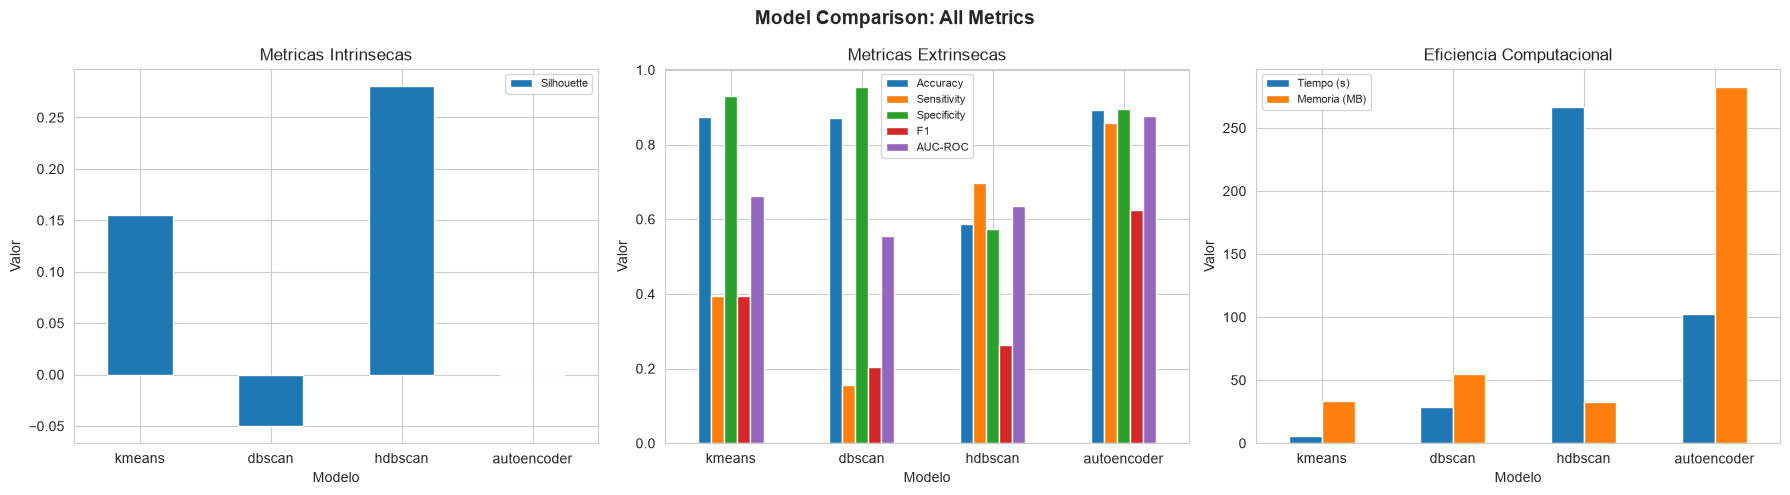

In [8]:
plot_metrics_comparison(results_df, title="Model Comparison: All Metrics")

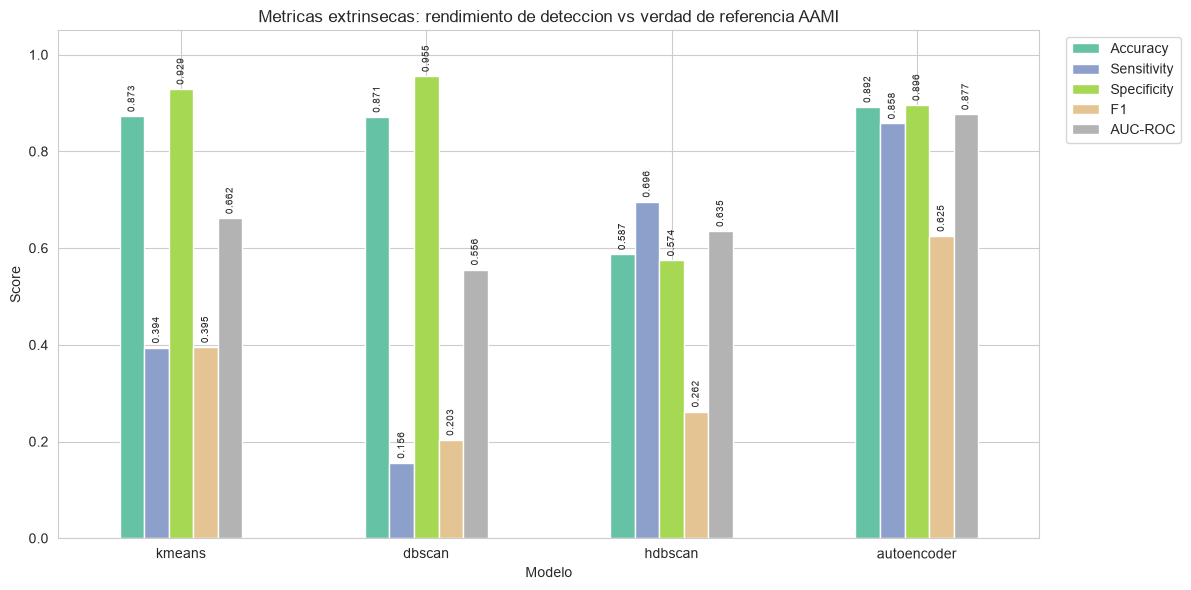

In [9]:
# Focused extrinsic metrics bar chart
extrinsic_cols = ["Accuracy", "Sensitivity", "Specificity", "F1", "AUC-ROC"]
available_ext = [c for c in extrinsic_cols if c in results_df.columns]

if available_ext:
    plot_data = results_df[["Modelo"] + available_ext].set_index("Modelo")
    plot_data = plot_data.apply(pd.to_numeric, errors="coerce")

    fig, ax = plt.subplots(figsize=(12, 6))
    plot_data.plot(kind="bar", ax=ax, rot=0, colormap="Set2")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_title(LABELS_ES["Extrinsic Metrics: Detection Performance vs AAMI Ground Truth"])
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=7, rotation=90, padding=3)

    plt.tight_layout()
    plt.show()

## 5. Matrices de Confusión

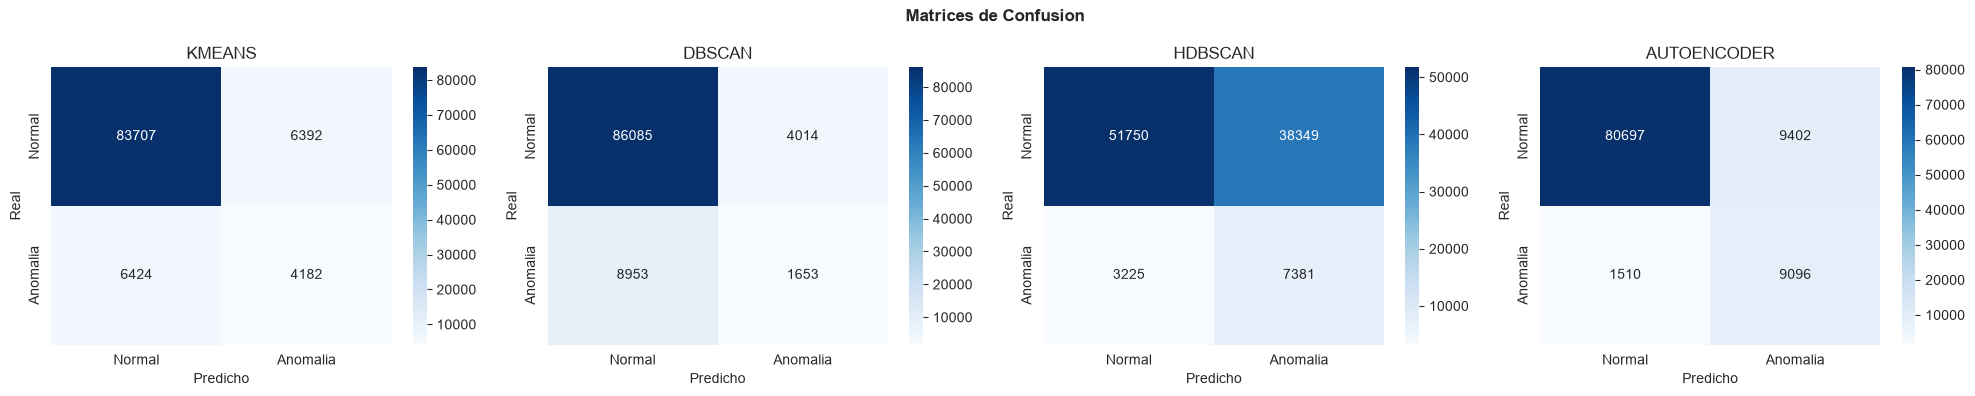

In [10]:
plot_confusion_matrices(comparator.results)

In [11]:
# Detailed confusion matrix breakdown
for result in comparator.results:
    model = result["model"]
    tp = result.get("extrinsic_true_positives", 0)
    fp = result.get("extrinsic_false_positives", 0)
    tn = result.get("extrinsic_true_negatives", 0)
    fn = result.get("extrinsic_false_negatives", 0)
    print(f"\n{model.upper()}:")
    print(f"  True Positives (correct anomalies):  {tp:,}")
    print(f"  False Positives (false alarms):      {fp:,}")
    print(f"  True Negatives (correct normals):    {tn:,}")
    print(f"  False Negatives (missed anomalies):  {fn:,}")


KMEANS:
  True Positives (correct anomalies):  4,182
  False Positives (false alarms):      6,392
  True Negatives (correct normals):    83,707
  False Negatives (missed anomalies):  6,424

DBSCAN:
  True Positives (correct anomalies):  1,653
  False Positives (false alarms):      4,014
  True Negatives (correct normals):    86,085
  False Negatives (missed anomalies):  8,953

HDBSCAN:
  True Positives (correct anomalies):  7,381
  False Positives (false alarms):      38,349
  True Negatives (correct normals):    51,750
  False Negatives (missed anomalies):  3,225

AUTOENCODER:
  True Positives (correct anomalies):  9,096
  False Positives (false alarms):      9,402
  True Negatives (correct normals):    80,697
  False Negatives (missed anomalies):  1,510


## 6. Dispersión PCA: Verdad de Campo vs Predicciones

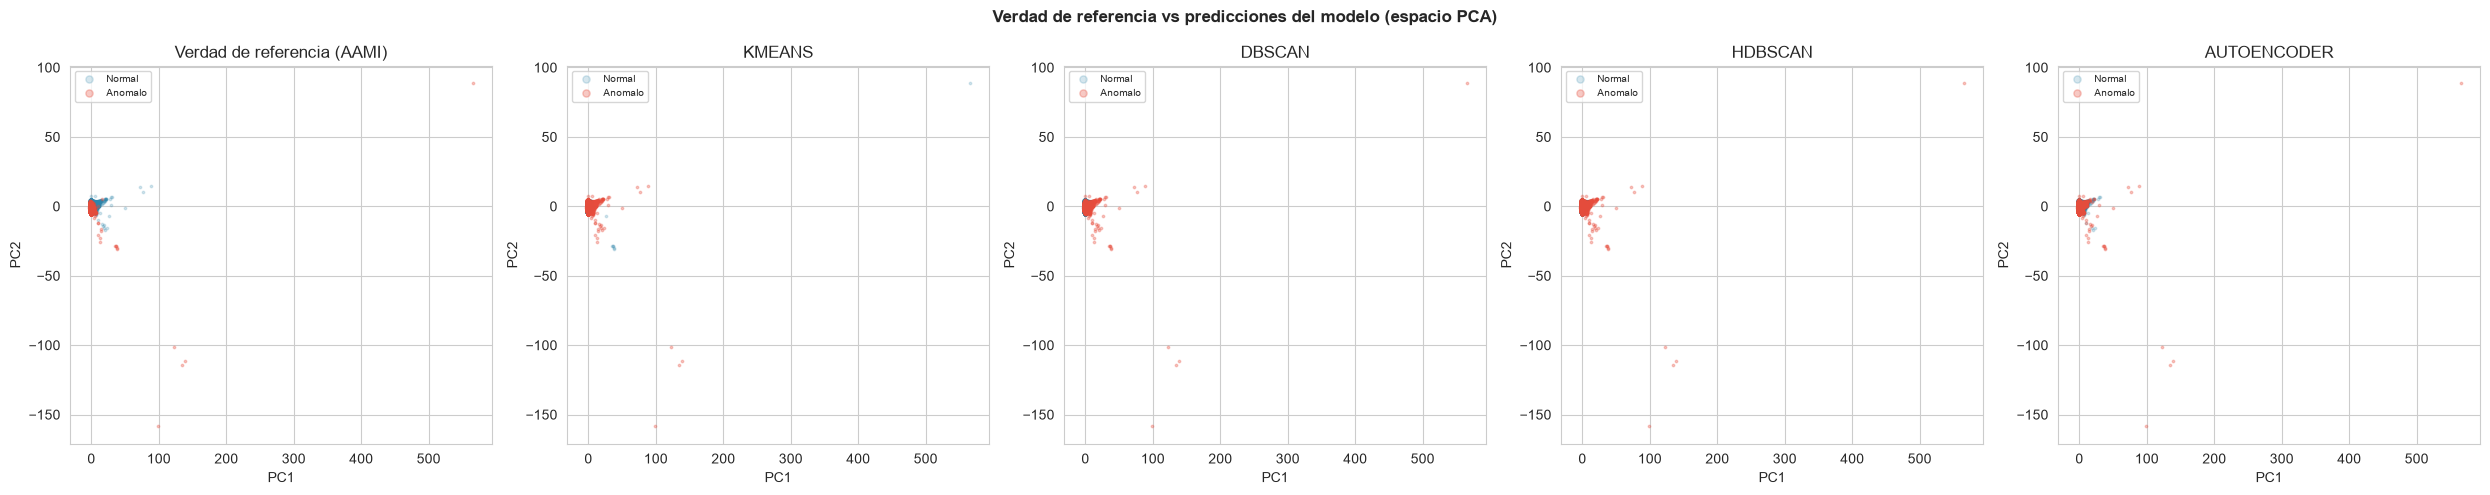

In [12]:
fig, axes = plt.subplots(1, len(config.models) + 1, figsize=(5 * (len(config.models) + 1), 5))

# Ground truth
normal_mask = true_labels == 0
anomaly_mask = true_labels == 1
axes[0].scatter(X_pca_vis[normal_mask, 0], X_pca_vis[normal_mask, 1],
               alpha=0.2, s=3, c="#2E86AB", label="Normal")
axes[0].scatter(X_pca_vis[anomaly_mask, 0], X_pca_vis[anomaly_mask, 1],
               alpha=0.3, s=3, c="#E74C3C", label=LABELS_ES["Anomalous"])
axes[0].set_title(LABELS_ES["Ground Truth (AAMI)"])
axes[0].legend(fontsize=7, markerscale=3)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Each model's predictions
for i, model_name in enumerate(config.models):
    detector = comparator.detectors[i]
    if detector.anomaly_labels_ is not None:
        pred_normal = detector.anomaly_labels_ == 0
        pred_anomaly = detector.anomaly_labels_ == 1
        axes[i+1].scatter(X_pca_vis[pred_normal, 0], X_pca_vis[pred_normal, 1],
                         alpha=0.2, s=3, c="#2E86AB", label="Normal")
        axes[i+1].scatter(X_pca_vis[pred_anomaly, 0], X_pca_vis[pred_anomaly, 1],
                         alpha=0.3, s=3, c="#E74C3C", label=LABELS_ES["Anomaly"])
        axes[i+1].legend(fontsize=7, markerscale=3)
    axes[i+1].set_title(f"{model_name.upper()}")
    axes[i+1].set_xlabel("PC1")
    axes[i+1].set_ylabel("PC2")

plt.suptitle(LABELS_ES["Ground Truth vs Model Predictions (PCA Space)"], fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Comparación de Eficiencia

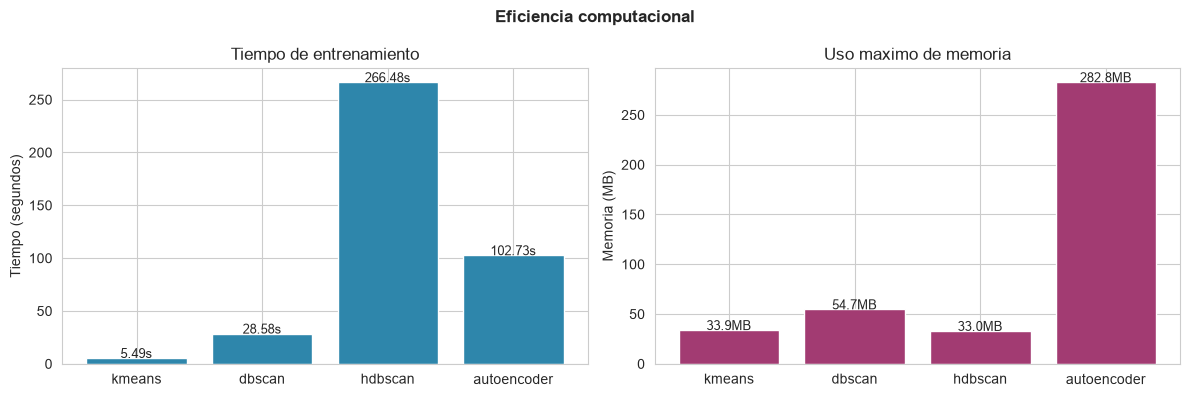

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = [r["model"] for r in comparator.results]
times = [r.get("efficiency_time_seconds", 0) for r in comparator.results]
memory = [r.get("efficiency_peak_memory_mb", 0) for r in comparator.results]

axes[0].bar(models, times, color="#2E86AB")
axes[0].set_ylabel(LABELS_ES["Time (seconds)"])
axes[0].set_title(LABELS_ES["Training Time"])
for i, v in enumerate(times):
    axes[0].text(i, v + 0.01, f"{v:.2f}s", ha="center", fontsize=9)

axes[1].bar(models, memory, color="#A23B72")
axes[1].set_ylabel(LABELS_ES["Memory (MB)"])
axes[1].set_title(LABELS_ES["Peak Memory Usage"])
for i, v in enumerate(memory):
    axes[1].text(i, v + 0.01, f"{v:.1f}MB", ha="center", fontsize=9)

plt.suptitle(LABELS_ES["Computational Efficiency"], fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Selección del Mejor Modelo

In [14]:
# Determine best model by F1 score
best_f1 = comparator.get_best_model(metric="extrinsic_f1")
best_acc = comparator.get_best_model(metric="extrinsic_accuracy")
best_sens = comparator.get_best_model(metric="extrinsic_sensitivity")
best_time = comparator.get_best_model(metric="efficiency_time_seconds")

print("Best model by metric:")
print(f"  F1 Score:    {best_f1}")
print(f"  Accuracy:    {best_acc}")
print(f"  Sensitivity: {best_sens}")
print(f"  Speed:       {best_time}")
print()
print(f"Overall recommendation (by F1): {best_f1}")

Best model by metric:
  F1 Score:    autoencoder
  Accuracy:    autoencoder
  Sensitivity: autoencoder
  Speed:       kmeans

Overall recommendation (by F1): autoencoder


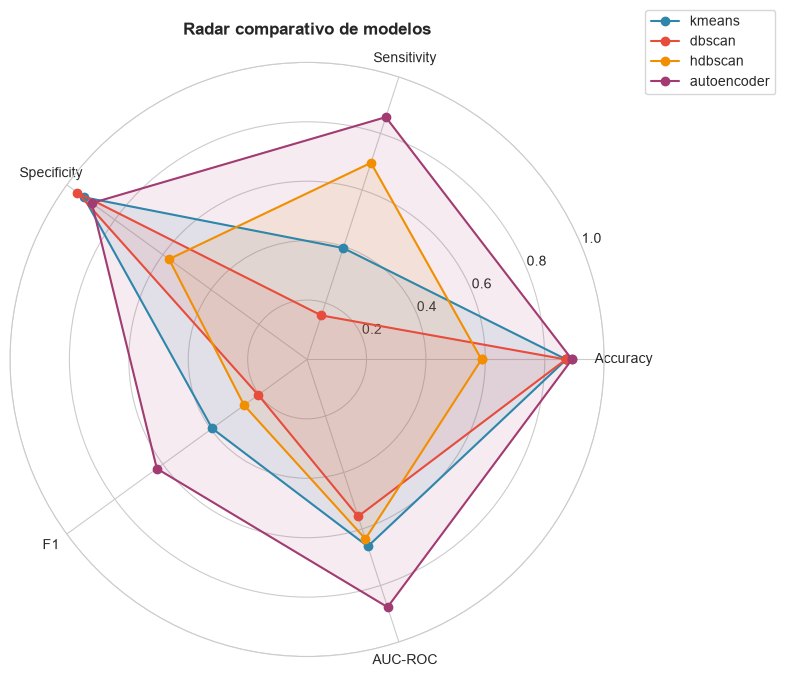

In [15]:
# Radar chart for multi-metric comparison
radar_metrics = ["Accuracy", "Sensitivity", "Specificity", "F1", "AUC-ROC"]
available_radar = [m for m in radar_metrics if m in results_df.columns]

if len(available_radar) >= 3:
    from matplotlib.patches import FancyBboxPatch
    angles = np.linspace(0, 2 * np.pi, len(available_radar), endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors = ["#2E86AB", "#E74C3C", "#F18F01", "#A23B72"]

    for i, row in results_df.iterrows():
        values = [float(row[m]) if pd.notna(row[m]) else 0 for m in available_radar]
        values += values[:1]
        ax.plot(angles, values, "o-", linewidth=1.5, label=row["Modelo"],
                color=colors[i % len(colors)])
        ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(available_radar)
    ax.set_ylim(0, 1)
    ax.set_title(LABELS_ES["Model Comparison Radar"], pad=20, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

## 9. Seleccion del modelo: ranking extrinseco y diagnostico intrinseco

Las metricas usadas en este notebook responden preguntas distintas:

| Tipo | Metricas | Pregunta que responde |
|---|---|---|
| **Extrinsecas** | F1, Sensitivity, Specificity, AUC-ROC | ¿Que tan bien detecta el modelo las arritmias reales (contra ground truth AAMI)? |
| **Intrinsecas** | Silhouette, Davies-Bouldin, Calinski-Harabasz | ¿Que tan bien separados quedan los clusters geometricamente (sin usar etiquetas)? |
| **Eficiencia** | Tiempo, Memoria | ¿Cuanto cuesta computacionalmente entrenar el modelo? |

### Por que la seleccion se decide solo con metricas extrinsecas

En la evaluacion de esta tesis si se dispone de ground truth AAMI, asi que la
pregunta "¿cual modelo detecta mejor las arritmias?" se responde directamente
con F1, Sensitivity, Specificity y AUC-ROC -- no con un promedio que mezcle
velocidad o geometria de clusters con capacidad de deteccion. Un modelo puede
subir en un ranking combinado por ser rapido o por tener clusters compactos,
aunque detecte mal las arritmias.

Las metricas intrinsecas se muestran por separado, como **diagnostico de
estructura**: informan si el modelo encontro una geometria de clusters
razonable, pero no deciden cual modelo es el mejor detector. Por ejemplo, un
buen Silhouette no implica buena deteccion si el modelo genera muchas falsas
alarmas (Specificity baja).

### Puntaje absoluto, no relativo

A diferencia de un ranking normalizado min-max (donde un modelo obtiene 1.0 en
una metrica solo por ser el mejor de este grupo particular de modelos), aqui
cada metrica extrinseca se reporta en su escala natural [0, 1]: un F1 de 0.625
vale 0.625, sin importar contra que otros modelos compita. Es un puntaje
absoluto y honesto de que tan bien detecta cada modelo.


In [16]:
# ============================================================
# SELECCION DEL MEJOR MODELO: solo metricas EXTRINSECAS
# ============================================================
# En la evaluacion de la tesis SI tenemos ground truth AAMI, por lo
# que "cual detecta mejor las arritmias" se responde con metricas
# extrinsecas, no con un promedio que mezcle geometria y eficiencia.

seleccion = results_df[[
    "Modelo", "F1", "Sensitivity", "Specificity", "AUC-ROC"
]].copy()
seleccion = seleccion.sort_values("F1", ascending=False).reset_index(drop=True)
seleccion.index = seleccion.index + 1
seleccion.index.name = "Rank"

print("=" * 60)
print("RANKING DE SELECCION (deteccion de anomalias)")
print("Criterio principal: F1 sobre la clase anomala")
print("=" * 60)
display(seleccion.round(4))

mejor = seleccion.iloc[0]["Modelo"]
print(f"\nMejor modelo detector: {mejor.upper()} "
      f"(F1={seleccion.iloc[0]['F1']:.4f})")

# ============================================================
# DIAGNOSTICO DE ESTRUCTURA: metricas INTRINSECAS (informativo)
# ============================================================
# NO deciden la seleccion. Miden la geometria del clustering.
# El autoencoder no produce clusters -> Silhouette = NaN (esperado).

intrinsecas = results_df[[
    "Modelo", "Silhouette", "Davies-Bouldin", "Calinski-Harabasz"
]].copy()
print("\n" + "=" * 60)
print("DIAGNOSTICO DE ESTRUCTURA (informativo, NO decide la seleccion)")
print("=" * 60)
display(intrinsecas.round(4))

print("\nNota: un buen Silhouette (ej. HDBSCAN=0.28) NO implica buena")
print("deteccion. HDBSCAN agrupa bien geometricamente pero genera muchas")
print("falsas alarmas (Especificidad baja). Por eso las intrinsecas")
print("informan la estructura, pero la seleccion la deciden las extrinsecas.")


RANKING DE SELECCION (deteccion de anomalias)
Criterio principal: F1 sobre la clase anomala


,Modelo,F1,Sensitivity,Specificity,AUC-ROC
Rank,,,,,
1,autoencoder,0.6251,0.8576,0.8956,0.8766
2,kmeans,0.3949,0.3943,0.9291,0.6617
3,hdbscan,0.2620,0.6959,0.5744,0.6351
4,dbscan,0.2032,0.1559,0.9554,0.5557



Mejor modelo detector: AUTOENCODER (F1=0.6251)

DIAGNOSTICO DE ESTRUCTURA (informativo, NO decide la seleccion)


,Modelo,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,kmeans,0.1549,1.1626,15484.3949
1,dbscan,-0.0501,1.0692,284.3208
2,hdbscan,0.2809,1.2430,2737.7120
3,autoencoder,NaN,NaN,NaN



Nota: un buen Silhouette (ej. HDBSCAN=0.28) NO implica buena
deteccion. HDBSCAN agrupa bien geometricamente pero genera muchas
falsas alarmas (Especificidad baja). Por eso las intrinsecas
informan la estructura, pero la seleccion la deciden las extrinsecas.


### 9b. Ranking por escenario clinico

El ranking anterior (F1) refleja un criterio unico y objetivo: la capacidad
global de deteccion. Sin embargo, en la practica clinica la importancia
relativa de cada metrica extrinseca depende del escenario de uso. Los
escenarios se calculan unicamente sobre metricas extrinsecas, ya que la
eficiencia computacional y la geometria de clusters no deben influir en el
criterio de deteccion clinica.

| Escenario | Prioridad | Pesos |
|-----------|-----------|-------|
| **Screening poblacional** | No dejar pasar ninguna anomalia | Sensitivity 45%, F1 35%, AUC-ROC 15%, Specificity 5% |
| **Diagnostico clinico** | Evitar falsas alarmas y procedimientos innecesarios | Specificity 40%, F1 35%, AUC-ROC 15%, Sensitivity 10% |
| **Equilibrado** | Balance general | F1 40%, Sensitivity 30%, Specificity 30% |

Cada escenario pondera solo metricas extrinsecas, ya en escala [0, 1], y sus
pesos suman 1.0, por lo que el puntaje resultante es interpretable
directamente como una proporcion -- sin normalizacion relativa entre modelos.

A continuacion se calculan los rankings para los tres escenarios, permitiendo
observar como cambia la seleccion del mejor modelo segun la prioridad
clinica.

Referencias:
- Triantaphyllou (2000). *Multi-Criteria Decision Making: A Comparative Study.* Springer.
  [DOI](https://link.springer.com/book/10.1007/978-1-4757-3157-6)
- Hwang & Yoon (1981). *Multiple Attribute Decision Making.* Springer-Verlag.
  [DOI](https://doi.org/10.1007/978-3-642-48318-9)
- Saaty (2008). *Decision making with the analytic hierarchy process.* Int. J. Services Sciences, 1(1), 83-98.
  [DOI](https://doi.org/10.1504/IJSSCI.2008.017590)


RANKING POR ESCENARIO CLINICO (metricas extrinsecas)


,Screening,Diagnostico,Equilibrado
Modelo,,,
autoencoder,0.7810,0.7943,0.7760
kmeans,0.4614,0.6485,0.5550
hdbscan,0.5289,0.4863,0.4859
dbscan,0.2724,0.5522,0.4147


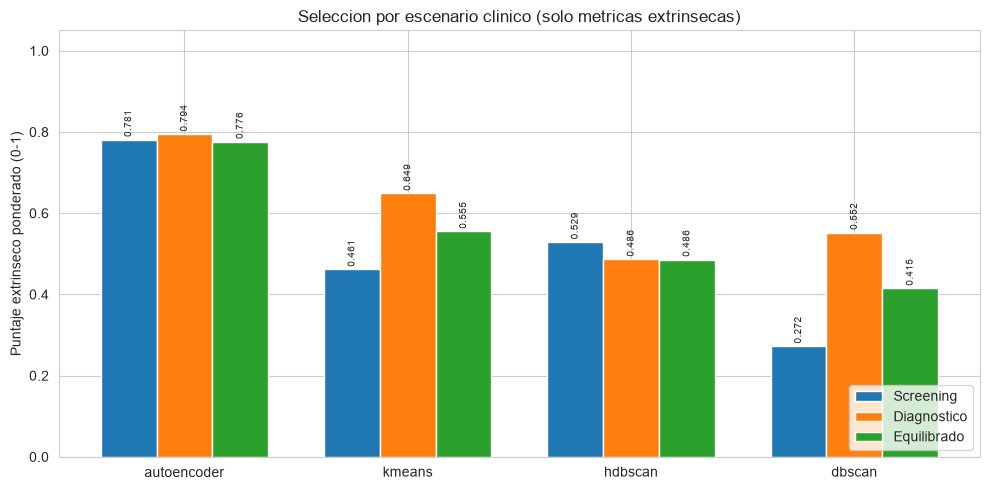


Interpretacion:
- En Screening: mejor modelo = autoencoder (puntaje=0.7810)
- En Diagnostico: mejor modelo = autoencoder (puntaje=0.7943)
- En Equilibrado: mejor modelo = autoencoder (puntaje=0.7760)


In [17]:
# ============================================================
# ESCENARIOS CLINICOS: ranking por metricas extrinsecas puras
# (sin Composite, sin get_multi_criteria_ranking)
# ============================================================
# Cada escenario pondera SOLO metricas extrinsecas. Estas ya estan
# en escala [0,1] (son proporciones), asi que la suma ponderada es
# directa y NO necesita normalizacion relativa entre modelos.

def score_extrinseco(df, pesos):
    """Suma ponderada de metricas extrinsecas ya en escala [0,1]."""
    s = pd.Series(0.0, index=df.index)
    for col, w in pesos.items():
        s = s + df[col].fillna(0.0) * w
    return s


escenarios = {
    "Screening":   {"Sensitivity": 0.45, "F1": 0.35, "AUC-ROC": 0.15, "Specificity": 0.05},
    "Diagnostico": {"Specificity": 0.40, "F1": 0.35, "AUC-ROC": 0.15, "Sensitivity": 0.10},
    "Equilibrado": {"F1": 0.40, "Sensitivity": 0.30, "Specificity": 0.30},
}

comparison = pd.DataFrame({"Modelo": results_df["Modelo"].values})
for nombre, pesos in escenarios.items():
    comparison[nombre] = score_extrinseco(results_df, pesos).values

comparison = comparison.set_index("Modelo")
comparison = comparison.sort_values("Equilibrado", ascending=False)

print("=" * 60)
print("RANKING POR ESCENARIO CLINICO (metricas extrinsecas)")
print("=" * 60)
display(comparison.round(4))

# Grafico de barras por escenario
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
width = 0.25
for i, nombre in enumerate(escenarios):
    bars = ax.bar(x + width * i, comparison[nombre].values, width, label=nombre)
    ax.bar_label(bars, fmt="%.3f", fontsize=7, rotation=90, padding=2)

ax.set_xticks(x + width)
ax.set_xticklabels(comparison.index)
ax.set_ylabel("Puntaje extrinseco ponderado (0-1)")
ax.set_ylim(0, 1.05)
ax.set_title("Seleccion por escenario clinico (solo metricas extrinsecas)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\nInterpretacion:")
for nombre in escenarios:
    top = comparison[nombre].idxmax()
    val = comparison[nombre].max()
    print(f"- En {nombre}: mejor modelo = {top} (puntaje={val:.4f})")


## Resumen

### Hallazgos Clave

La evaluación comparativa analizó 4 métodos no supervisados para detección de anomalías en ECG:

| Método | Enfoque | Fortalezas |
|---|---|---|
| KMeans | Basado en particiones (k=2) | Rápido, línea base simple |
| DBSCAN | Basado en densidad | No requiere k, encuentra ruido |
| HDBSCAN | Densidad jerárquica | Maneja densidades variables |
| Autoencoder | Error de reconstrucción | Aprende patrones complejos |

### Marco de Evaluación
- **Métricas intrínsecas** evalúan la calidad del cluster sin etiquetas
- **Métricas extrínsecas** comparan contra anotaciones clínicas AAMI
- **Métricas de eficiencia** miden el costo computacional

### Seleccion final

Bajo el criterio extrinseco puro (Seccion 9), el **Autoencoder** es el mejor
detector: obtiene el F1 mas alto de los cuatro metodos, evaluado directamente
contra las anotaciones AAMI. Las metricas intrinsecas (Silhouette,
Davies-Bouldin) informan la calidad geometrica del clustering, pero no
participan en esta decision -- un buen Silhouette no implica buena deteccion
clinica. El ranking por escenario (Seccion 9b) muestra que esta seleccion es
razonablemente estable frente a distintas prioridades clinicas (screening,
diagnostico, equilibrado).


## Referencias

### Validación de clustering (Sección 1b-1d)

1. Rendón, E., Abundez, I., Arizmendi, A. & Quiroz, E. M. (2011). *Internal versus external cluster validation indexes.* International Journal of Computers and Communications.
   [PDF](https://www.wseas.us/e-library/conferences/2011/Mexico/CEMATH/CEMATH-26.pdf)

2. Halkidi, M., Batistakis, Y. & Vazirgiannis, M. (2001). *On clustering validation techniques.* Journal of Intelligent Information Systems, 17(2-3), 107-145.
   https://doi.org/10.1023/A:1012801612483

3. Liu, Y., Li, Z., Xiong, H., Gao, X. & Wu, J. (2010). *Understanding of internal clustering validation measures.* IEEE International Conference on Data Mining (ICDM), 911-916.
   https://doi.org/10.1109/ICDM.2010.35

4. Moody, G. B. & Mark, R. G. (2001). *The impact of the MIT-BIH Arrhythmia Database.* IEEE Engineering in Medicine and Biology Magazine, 20(3), 45-50.
   https://doi.org/10.1109/51.932724

### Ranking multi-criterio (Sección 9)

5. Hwang, C. L. & Yoon, K. (1981). *Multiple Attribute Decision Making: Methods and Applications.* Springer-Verlag.
   https://doi.org/10.1007/978-3-642-48318-9

6. Triantaphyllou, E. (2000). *Multi-Criteria Decision Making: A Comparative Study.* Kluwer Academic Publishers.
   https://link.springer.com/book/10.1007/978-1-4757-3157-6

7. Fishburn, P. C. (1967). *Additive Utilities with Incomplete Product Set: Applications to Priorities and Assignments.* Journal of the Operations Research Society of America, 15(3), 537-542.
   https://doi.org/10.1287/opre.15.3.537

### Sistemas de soporte a decisiones clínicas (Frontend)

8. Sutton, R. T., Pincock, D., Baumgart, D. C., Sadowski, D. C., Fedorak, R. N. & Kroeker, K. I. (2020). *An overview of clinical decision support systems: benefits, risks, and strategies for success.* NPJ Digital Medicine, 3, 17.
   https://doi.org/10.1038/s41746-020-0221-y

### Clasificación de latidos ECG

9. de Chazal, P., O'Dwyer, M. & Reilly, R. B. (2004). *Automatic classification of heartbeats using ECG morphology and heartbeat interval features.* IEEE Transactions on Biomedical Engineering, 51(7), 1196-1206.
   https://doi.org/10.1109/TBME.2004.827359